---
### General Imports
- Code cell to import necessary modules and dependencies. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, TunedThresholdClassifierCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.ensemble import GradientBoostingClassifier



---
### Threshold Tuning - `Precision-Recall Curve`
- The code block shows how to find the best threshold using the `precision_recall_curve`'s output scores. 

In [ ]:
X, y = make_classification(
    n_samples=3000, n_features=10, n_informative=5,
    weights=[0.9, 0.1], random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_proba = clf.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * precisions * recalls / (precisions + recalls)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label='Precision')
ax.plot(thresholds, recalls[:-1], label='Recall')
ax.plot(thresholds, f1_scores[:-1], label='F1_score')
ax.axvline(best_threshold, linestyle='--', color='grey', label=f'Best F1@t={best_threshold:.3f}')
ax.set_ylabel('Thresholds')
ax.set_xlabel('Scores')

plt.title('Yeahhhhhh Bitch')
plt.legend()
plt.tight_layout()
plt.show()

---
### F-Beta Search
- basically using a different number from 2 when computing F1. 
- at beta == 1, (1 + 1²) * precisions * recalls / (beta² * precisions+recalls) <- Normal f1. 

In [53]:
for beta in [0.5, 1, 2]:
    fbeta_scores = (1 + beta**2) * precisions * recalls / (beta**2 * precisions + recalls)
    best_fbeta_idx = np.argmax(fbeta_scores[:-1])
    print(f"beta={beta:<4}: Threshold={thresholds[best_fbeta_idx]:.3f} F({beta})={fbeta_scores[best_fbeta_idx]:.3f}")
  


beta=0.5 : Threshold=0.545 F(0.5)=0.688
beta=1   : Threshold=0.307 F(1)=0.513
beta=2   : Threshold=0.132 F(2)=0.511


---
### `TunedThresholdClassifierCV`
- Code cell for using scikit-learn's built-in `TunedThresholdClassifierCV`
- Pros: No leakages or anything.

In [61]:
tuned_clf = TunedThresholdClassifierCV(
    estimator=LogisticRegression(), 
    scoring='f1',
    cv=StratifiedKFold(5),
    random_state=42,
    store_cv_results=True
)

tuned_clf.fit(X_train, y_train)

tuned_clf.best_threshold_


np.float64(0.2790584754958137)

---
### Cost-Driven Threshold Searching/Tuning
 - Based on cost of errors for example FN can be 5X more costly than FP. 

In [ ]:
COST_FP = 1
COST_FN = 5

costs = []
for t in thresholds:
    y_pred_t = (y_proba > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    tot = COST_FP * fp + COST_FN * fn
    costs.append(tot)
    
costs = np.array(costs)
best_idx = np.argmin(costs)
thresholds[best_idx], costs[best_idx]


(np.float64(0.2209208878891101), np.int64(288))

---
### Calibration
- Calibration and Calibration Curves
- Brier Score
- Platt Scaling, Isotonic Regression. 

-----------SCORES------------------------
    Base Brier Score: 0.053
    Platt Brier Score: 0.052
    Isotonic Brier Score: 0.052    


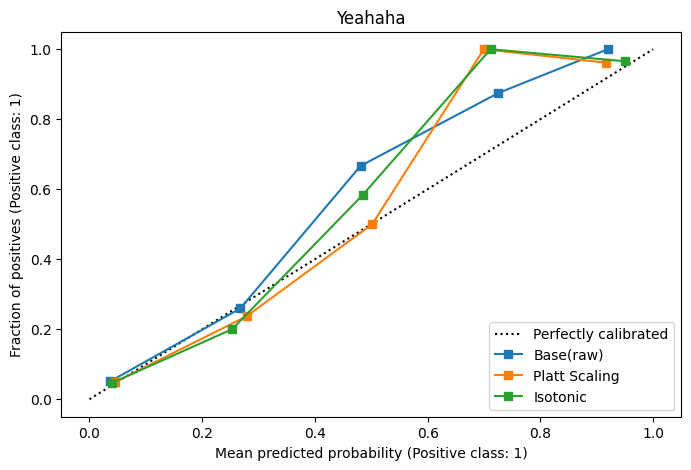

In [7]:
X, y = make_classification(
    n_samples=3000, n_features=10, n_informative=5,
    weights=[0.9, 0.1], random_state=42
)

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
gb = GradientBoostingClassifier(random_state=42).fit(Xtrain, ytrain)
y_prob = gb.predict_proba(Xtest)[:, 1]

cal_platt = CalibratedClassifierCV(
    estimator=GradientBoostingClassifier(random_state=42),
    method='sigmoid',
    cv=StratifiedKFold(5)
).fit(Xtrain, ytrain)
plat_prob = cal_platt.predict_proba(Xtest)[:, 1]

cal_iso = CalibratedClassifierCV(
    estimator=GradientBoostingClassifier(random_state=42),
    method='isotonic',
    cv=StratifiedKFold(5)
).fit(Xtrain, ytrain)
cal_prob = cal_iso.predict_proba(Xtest)[:, 1]

print(f"-----------SCORES------------------------\n\
    Base Brier Score: {brier_score_loss(ytest, y_prob):.3f}\n\
    Platt Brier Score: {brier_score_loss(ytest, plat_prob):.3f}\n\
    Isotonic Brier Score: {brier_score_loss(ytest, cal_prob):.3f}\
    ")

fig, ax = plt.subplots(figsize=(8, 5))
CalibrationDisplay.from_predictions(ytest, y_prob, n_bins=5, ref_line=True, ax=ax, name="Base(raw)")
CalibrationDisplay.from_predictions(ytest, plat_prob, n_bins=5, ref_line=True, ax=ax, name="Platt Scaling")
CalibrationDisplay.from_predictions(ytest, cal_prob, n_bins=5, ref_line=True, ax=ax, name="Isotonic")

ax.set_title("Yeahaha")
plt.show()


In [ ]:
def function(X: dict) -> dict:
    """Yoooo Justtrying

    Args:
        X (dict): A dictionary object

    Returns:
        dict: A dictionary
    """
    return X



In [ ]:

X, y = load_iris(as_frame=True, return_X_y=True)
df = pd.concat([X, y], axis=1)

# df['target'] = df['target'].map({0: 0, 1: 1, 2: np.nan})
# df = df.dropna()
df = df.drop(df[df['target'] == 2].index)
df['target'].value_counts()

target
0    50
1    50
Name: count, dtype: int64

In [57]:
np.random.seed(42)
data = np.random.normal(50, 5, 200)
data = np.append(data, [90, 95, 5, 2])

z_scores = np.abs(stats.zscore(data))
outliers = data[z_scores > 3]

q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers_iqr = data[(data < lower_fence) | (data > upper_fence)]
print(outliers_iqr)


[36.90127448 62.31621056 63.60084583 90.         95.          5.
  2.        ]


In [ ]:
import nltk

# Download required NLTK resources (only needs to run once per environment)
for resource in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(resource, quiet=True)

print("NLTK resources ready.")

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
messages = [
    "Free entry to win a prize call now",
    "Win cash money now free offer",
    "Hey, are you coming to the meeting?",
    "Let me know the project deadline",
    "FREE money claim your prize TODAY",
    "See you at the office tomorrow"
]

labels = [1, 1, 0, 0, 1, 0]
vect = CountVectorizer()
X = vect.fit_transform(messages)
tf = TfidfVectorizer()
Xt = tf.fit_transform(messages)
